# Find Satellites in GALEX-data
21.05.2026

@mauritz.wicker

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
from scipy import sparse
from scipy.sparse.linalg import spsolve
from time import perf_counter

from astropy.io import fits
from astropy.wcs import WCS

from matplotlib.colors import Normalize, LogNorm, SymLogNorm
import ipywidgets as widgets
from IPython.display import display

from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from astropy.visualization import ZScaleInterval, ImageNormalize, LinearStretch, LogStretch

import warnings
warnings.filterwarnings("ignore")

import matplotlib as mpl
from matplotlib.path import Path

from astropy.timeseries import LombScargle

In [2]:
import inout
import formatData
import runAnalysis

import plottingOutput
import motionAnalysis

In [23]:
pthData = '../data/'
dataName_e02419 = 'e02419-nd-b00.parquet'
dataName_e15391 = 'e15391-nd-b00.parquet'

dataName = dataName_e02419
nmNow = 'e02419'
dataName = dataName_e15391
nmNow = 'e15391'

In [24]:
## Load your data
df_org = inout.load_data(pthData, dataName)

Loaded e15391-nd-b00.parquet


In [25]:
## Clean your data
df_clean = formatData.cleanData(df_org)

df_flag0 = df_clean[['t', 'ra', 'dec']]

Dropping rows with flag != 0
Len df Before: 31511243
Len df After: 30682159
Dropping nan-rows
Len df Before: 30682159
Len df After: 30682159
30682159 rows in data
7 columns in data: ['t', 'flags', 'ra', 'dec', 'detrad', 'mask', 'response']


In [26]:
# BINNING 
# # IN RA and DEC
coordBin_arcsec = 180
coordBin_deg = coordBin_arcsec /60/60
# IN TIME
timeBin_s = 1

In [27]:
overlap_results = formatData.binData_overlap(
    dfNow=df_flag0,
    col_time="t",
    col_ra="ra",
    col_dec="dec",
    t_bin=timeBin_s,
    coord_bin_arcsec=coordBin_arcsec,
    grid_step_arcsec=coordBin_arcsec / 2,
    offset_mode="full",
)

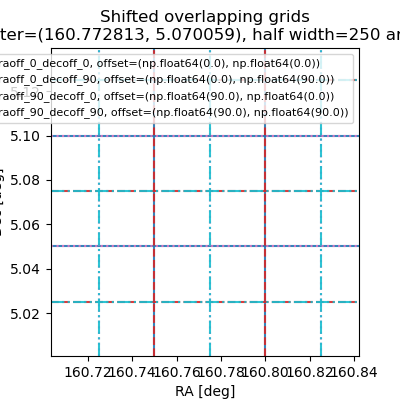

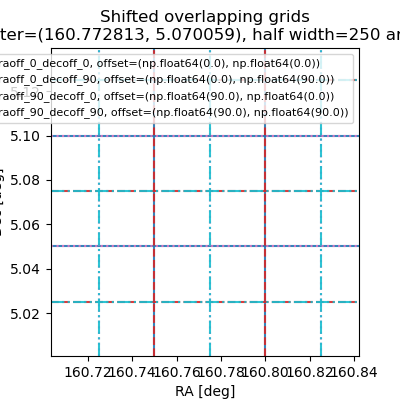

In [28]:
%matplotlib widget

formatData.plot_overlap_grid_lines_debug(
    df=df_flag0,
    overlap_results=overlap_results,
    col_ra="ra",
    col_dec="dec",
    ra_center=np.median(df_flag0['ra']),
    dec_center=np.median(df_flag0['dec']),
    half_width_arcsec=250,
    show_points=False,
)

plt.show()

In [29]:
use_OnlyCounts=False  # use counts or counts/med(counts)
maxRuns=1000
# Minimum relative counts (counts/med(counts))
counts_Min_rel = 0.75

In [30]:
resultsCandidates = runAnalysis.run_satFinder(overlap_results,use_OnlyCounts=use_OnlyCounts, maxRuns=maxRuns, pltIt=False, counts_Min_rel=counts_Min_rel, coordBin_arcsec=coordBin_arcsec,Xsig=5)

Working on raoff_0_decoff_0
cube shape: (1575, 28, 28)
min_total_counts: 6813.269987027084
Unable to fit Gaussian -> continue
Working on raoff_0_decoff_90
cube shape: (1575, 28, 27)
min_total_counts: 6383.57642047158
Unable to fit Gaussian -> continue
Working on raoff_90_decoff_0
cube shape: (1575, 27, 28)
min_total_counts: 6733.108594694055
Unable to fit Gaussian -> continue
Working on raoff_90_decoff_90
cube shape: (1575, 27, 27)
min_total_counts: 6161.845635548562
Unable to fit Gaussian -> continue


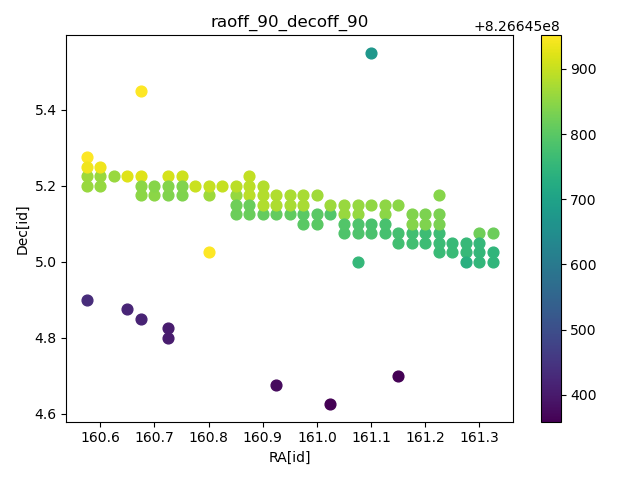

In [31]:
allData_final = plottingOutput.plotCandidates_A(resultsCandidates, overlap_results)

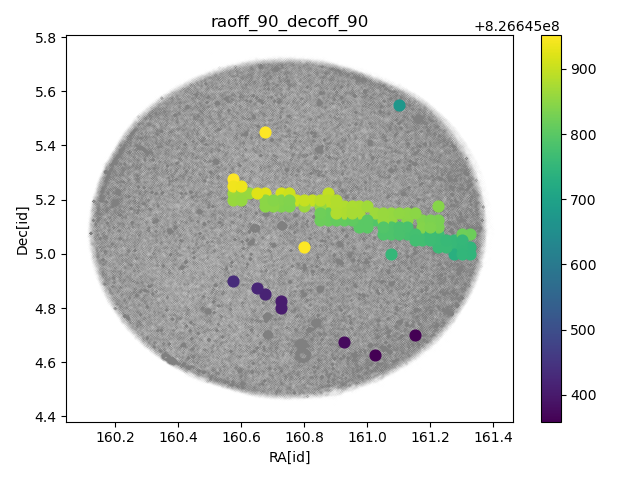

In [32]:
plottingOutput.plotCandidates_B(resultsCandidates, overlap_results, df_flag0)

In [33]:
df_final = formatData.allData_to_df(allData_final)

In [34]:
t0_e15391 = {'signal1': 8.26645e8,
                'signal2': 8.26645e8,
                'signal3': None}

dataCuts = {
    'e15391': {
        'radec_cuts': {
            'signal1': [[160.5, 5.321], [160.5, 5.147], [161.34, 4.94], [161.34, 5.247]],
            'signal2': [[160.5, 5.321], [160.5, 5.147], [161.34, 4.94], [161.34, 5.247]],
            'signal3': [[160.5, 5.0], [160.5, 4.60], [161.3, 4.75], [161.3, 4.4]]
        },
        'ratime_cuts': {
            'signal1': [
                [161.34, t0_e15391['signal1'] + 700],
                [161.34, t0_e15391['signal1'] + 800],
                [160.5, t0_e15391['signal1'] + 830],
                [160.5, t0_e15391['signal1'] + 900]
            ],
            'signal2': [
                [161.4, t0_e15391['signal2'] + 780],
                [161.4, t0_e15391['signal2'] + 840],
                [160.5, t0_e15391['signal2'] + 920],
                [160.5, t0_e15391['signal2'] + 975]
            ],
            'signal3': None
        },
        'dectime_cuts': {
            'signal1': None,
            'signal2': None,
            'signal3': None
        },
        'timeMin_cuts': {
            'signal1': None,
            'signal2': None,
            'signal3': 8.26645e8 + 250
        }
    },

    'e02419': {
        't0times_cuts': {'signal1': None},
        'radec_cuts': {'signal1': 
                        [[20.70, -33.38],
                        [20.90, -33.38],
                        [20.70, -33.22],
                        [20.90, -33.22]]},
        'ratime_cuts': {'signal1': None},
        'dectime_cuts': {'signal1': None},
        'timeMin_cuts': {'signal1': None}
    }
}

radec_cuts = dataCuts[nmNow]['radec_cuts']
ratime_cuts = dataCuts[nmNow]['ratime_cuts']
dectime_cuts = dataCuts[nmNow]['dectime_cuts']
timeMin_cuts = dataCuts[nmNow]['timeMin_cuts']

In [35]:
signalSelected = 'signal1'

radec_cut = radec_cuts[signalSelected]
ratime_cut = ratime_cuts[signalSelected]
dectime_cut = dectime_cuts[signalSelected]
timeMin_cut = timeMin_cuts[signalSelected]

df_final_cand0 = formatData.cut_for_one_satellite(
    df_final,
    signalSelected,
    radec_cut=radec_cut,
    ratime_cut=ratime_cut,
    dectime_cut=dectime_cut,
    timeMin_cut=timeMin_cut,
)

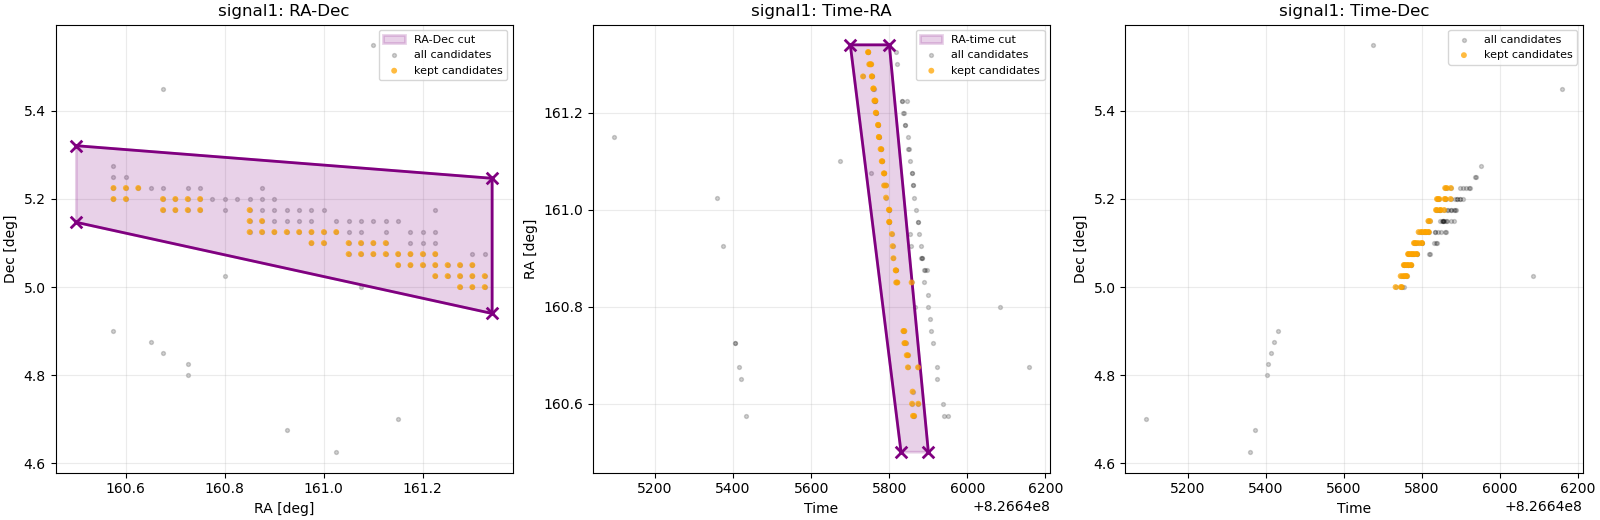

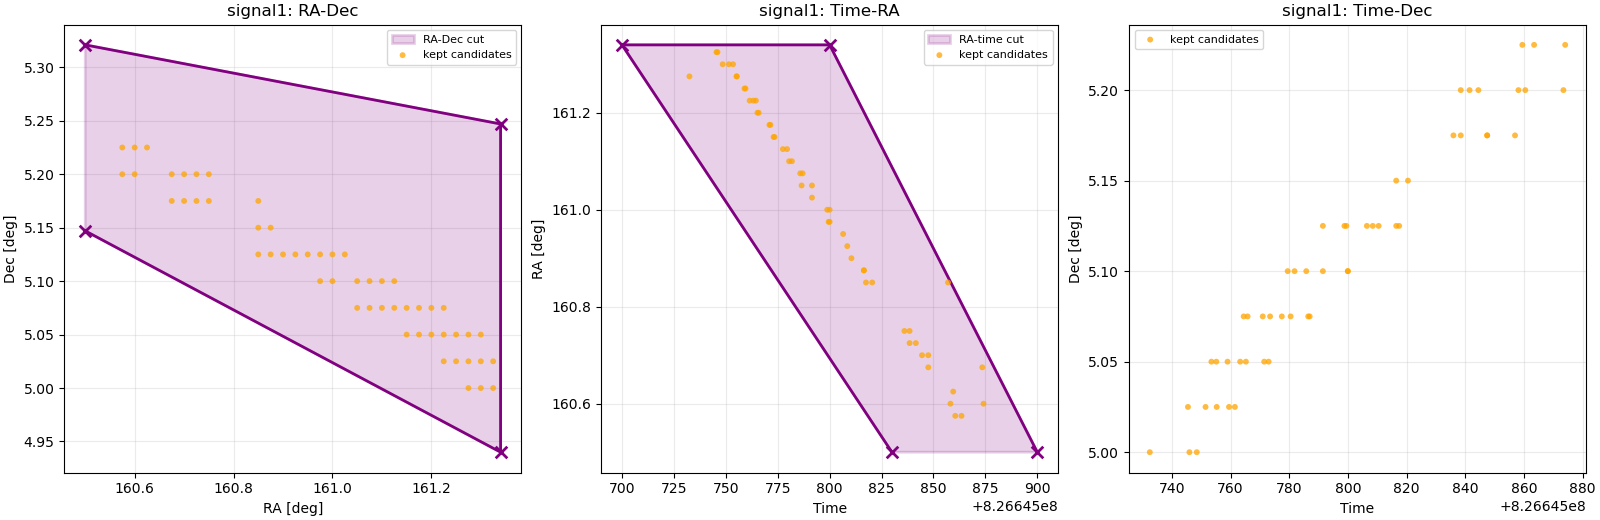

(<Figure size 1600x520 with 3 Axes>,
 array([<Axes: title={'center': 'signal1: RA-Dec'}, xlabel='RA [deg]', ylabel='Dec [deg]'>,
        <Axes: title={'center': 'signal1: Time-RA'}, xlabel='Time', ylabel='RA [deg]'>,
        <Axes: title={'center': 'signal1: Time-Dec'}, xlabel='Time', ylabel='Dec [deg]'>],
       dtype=object))

In [36]:
plottingOutput.plt_RegionCut(
    df_final,
    df_final_cand0,
    signalSelected,
    radec_cut,
    ratime_cut,
    dectime_cut,
    timeMin_cut,
    showFulLCands=True,
)

plottingOutput.plt_RegionCut(
    df_final,
    df_final_cand0,
    signalSelected,
    radec_cut,
    ratime_cut,
    dectime_cut,
    timeMin_cut,
    showFulLCands=False,
)


dRA/dt = -21.210 [arcsec / second]
dRA/dt = 5.857 [arcsec / second]


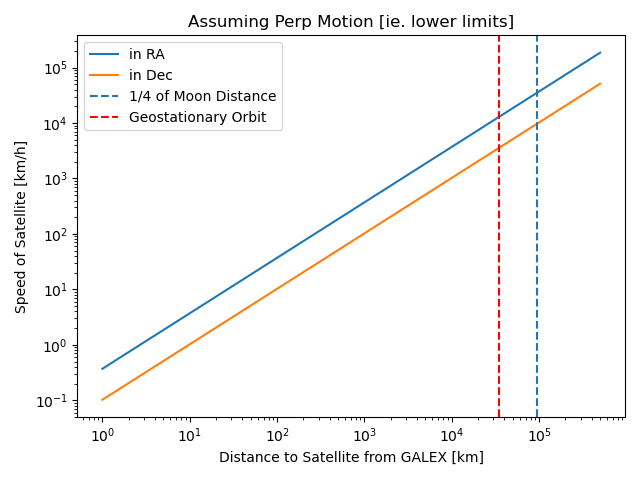

dRA/dt raw      = -21.210 arcsec/s
dRA/dt on sky   = -21.126 arcsec/s
dDec/dt         = 5.857 arcsec/s
Total sky speed = 21.923 arcsec/s
Speed at D=35786 km: 3.803 km/s
Speed at D=35786 km: 13692.5 km/h
Intersections:
Distance/altitude = 30601.98 km, speed = 11708.99 km/h


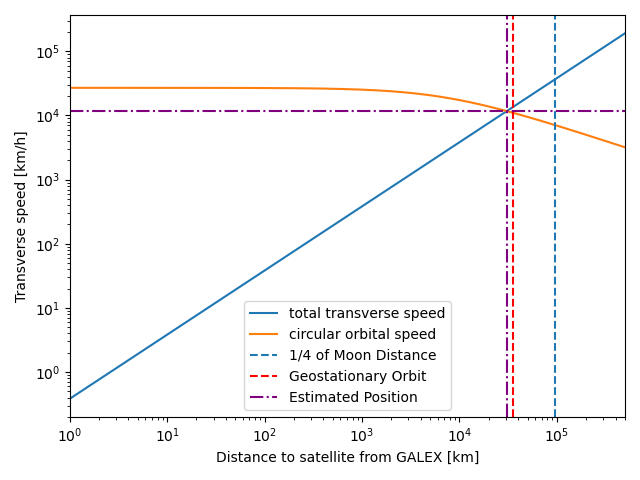

In [37]:
motionAnalysis.satelliteMotion(df_final_cand0)

In [38]:
# # nmNow = 'e02419'

# ## signal 12
# dRA/dt = -21.210 [arcsec / second]
# dRA/dt = 5.857 [arcsec / second]
# dRA/dt raw      = -21.210 arcsec/s
# dRA/dt on sky   = -21.126 arcsec/s
# dDec/dt         = 5.857 arcsec/s
# Total sky speed = 21.923 arcsec/s
# Speed at D=35786 km: 3.803 km/s
# Speed at D=35786 km: 13692.5 km/h
# Intersections:
# Distance/altitude = 30601.98 km, speed = 11708.99 km/h



# # signal 2
# dRA/dt = -21.443 [arcsec / second]
# dRA/dt = 4.923 [arcsec / second]
# dRA/dt raw      = -21.443 arcsec/s
# dRA/dt on sky   = -21.355 arcsec/s
# dDec/dt         = 4.923 arcsec/s
# Total sky speed = 21.916 arcsec/s
# Speed at D=35786 km: 3.802 km/s
# Speed at D=35786 km: 13688.2 km/h
# Intersections:
# Distance/altitude = 30608.91 km, speed = 11707.91 km/h


# dRA/dt = -21.874 [arcsec / second]
# dRA/dt = 14.148 [arcsec / second]
# dRA/dt raw      = -21.874 arcsec/s
# dRA/dt on sky   = -21.797 arcsec/s
# dDec/dt         = 14.148 arcsec/s
# Total sky speed = 25.986 arcsec/s
# Speed at D=35786 km: 4.508 km/s
# Speed at D=35786 km: 16230.6 km/h
# Intersections:
# Distance/altitude = 27104.86 km, speed = 12293.28 km/h



# nmNow = 'e15391'
# dRA/dt = -49.582 [arcsec / second]
# dRA/dt = -30.228 [arcsec / second]
# dRA/dt raw      = -49.582 arcsec/s
# dRA/dt on sky   = -41.436 arcsec/s
# dDec/dt         = -30.228 arcsec/s
# Total sky speed = 51.290 arcsec/s
# Speed at D=35786 km: 8.899 km/s
# Speed at D=35786 km: 32034.7 km/h
# Intersections:
# Distance/altitude = 16526.16 km, speed = 14793.78 km/h